In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import hanoi

Read data

In [3]:
d = pd.read_csv("data/L1_n1/L1_n1_gaus.txt", delimiter=" ")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
d.head()

In [ ]:
d_gb = d.groupby(["sigma", "m0", "m1", "v0", "v1"])

In [ ]:
d_gb

Extinction prob.

In [ ]:
d_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean")
        ).reset_index()

In [ ]:
d_1 = d[d["allele_fixed"] == 1].groupby(["sigma", "m0", "m1", "v0", "v1"])

In [ ]:
d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

In [ ]:
d_smr = pd.merge(d_gb.agg(
    p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
    p_fix_1 = ("allele_fixed", "mean")).reset_index(),
                 d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index(),
                 on = ["sigma", "m0", "m1", "v0", "v1"],
                 how = "left"
                )

In [ ]:
d_smr.head()

In [ ]:
d_smr.shape

In [ ]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [ ]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [ ]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [ ]:
def heatmap_panel(data, **kwargs):
    # pivot inside the panel
    table = data.pivot(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="coolwarm", vmin=0, vmax=1, cbar=False, ax=plt.gca())
    ax = plt.gca()
    ax.invert_yaxis()

    # Get current tick positions
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    # Set labels only for every 5th tick
    ax.set_xticklabels([f"$10^{{{int(np.log10(table.columns[int(t)]) )}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(xticks)], rotation=0)
    ax.set_yticklabels([f"$10^{{{int(np.log10(table.index[int(t)]))}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(yticks)])
    # Hide axis labels inside panel
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

In [4]:
z_1D = np.linspace(-5, 5, 101).reshape([101,1])

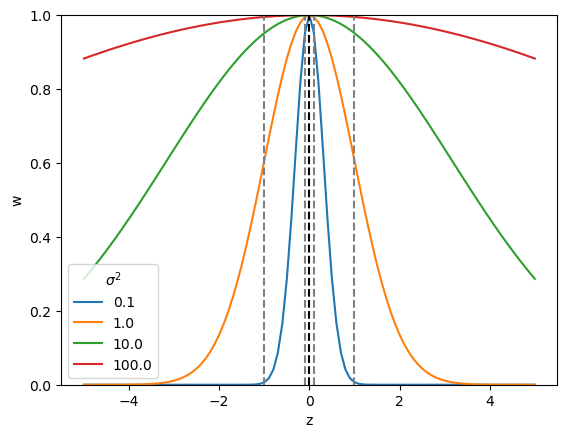

In [5]:
sigma2s = np.array([0.1,1,10, 100])
w_1D_s = np.array([hanoi.fit_gaus(z_opt = [0], sigma = np.sqrt(sigma2), z = z_1D) for sigma2 in sigma2s])
[plt.plot(z_1D, w_1D_s[i,:], label = sigma2s[i]) for i in range(len(sigma2s))]
plt.legend(title='$\sigma^2$')
plt.vlines(x=np.array([-1, -0.1, 0,0.1, 1]), ymin = 0, ymax = 1.1, colors = ["gray", "gray","black", "gray", "gray"], linestyles="--")
plt.xlabel("z")
plt.ylabel("w")
plt.ylim(0, 1)
plt.savefig("L1_n1_gaussian_fitness_funcs.pdf", bbox_inches="tight")
plt.show()

In [ ]:
d_smr["sigma"].unique()

In [ ]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()
    g.fig.savefig(f"L1_n1_gaussian_sigma2_{sigma**2}_summary.svg", format="svg", bbox_inches="tight")
    g.fig.savefig(f"L1_n1_gaussian_sigma2_{sigma**2}_summary.pdf", format="pdf", bbox_inches="tight")

In [ ]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()

In [ ]:
d_smr

In [ ]:
??hanoi.fit_gaus

In [ ]:
def heatmap_panel(data, value_col="p_fix_1", cmap="coolwarm", vmin=0, vmax=1, **kwargs):
    table = data.pivot(index="v1", columns="v0", values=value_col)
    ax = plt.gca()
    sns.heatmap(table, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.invert_yaxis()

    # nicer/robust tick handling: map tick positions to nearest column/index
    cols = np.array(table.columns, dtype=float)
    rows = np.array(table.index, dtype=float)
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    def tick_label_for_pos(pos_array, table_axis):
        # pos_array are tick positions; round to nearest integer index
        out = []
        for i, t in enumerate(pos_array):
            idx = int(round(t))
            if 0 <= idx < len(table_axis) and i % 5 == 0:
                out.append(f"$10^{{{int(np.log10(table_axis[idx]))}}}$")
            else:
                out.append("")
        return out

    ax.set_xticklabels(tick_label_for_pos(xticks, cols), rotation=0)
    ax.set_yticklabels(tick_label_for_pos(yticks, rows))
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

In [ ]:
value_col = "t_fix_1"   # the column you want to color by

for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]

    # choose vmin/vmax globally or per-sigma:
    vmin = d_smr_sub[value_col].min()
    vmax = d_smr_sub[value_col].max()

    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0",
                      row_order=row_order_m, col_order=col_order_m,
                      margin_titles=True)

    # pass value_col (and cmap/vmin/vmax) to your panel function
    g.map_dataframe(heatmap_panel, value_col=value_col, cmap="viridis",
                    vmin=vmin, vmax=vmax)

    g.fig.supxlabel("v0", x=0.5, y=0)
    g.fig.supylabel("v1", y=0.5, x=0)
    g.fig.suptitle(f"$\\sigma^2$ = {sigma ** 2}", x=0, y=1, ha="left")

    # colorbar next to last panel
    last_ax = g.axes[-1, -1]
    pos = last_ax.get_position()
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])

    # same cmap and normalization as used in heatmap
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cbar.set_label(f"${value_col}$", rotation=0, labelpad=10, va="center", ha="left")

    plt.show()

In [ ]:
d

In [ ]:
d_smr[d_smr["t_fix_1"].isna()]

In [ ]:
d[(d["sigma"] == 10) & (d["m0"] == 1) & (d["m1"] == 0.1) & (d["v0"] == 0.01) & (d["v1"] == 10)]["n_gen"].mean()

In [ ]:
value_col = "t_fix_1"  # column you want to color by

# choose vmin/vmax globally or per-subset
vmin = d_smr[value_col].min()
vmax = d_smr[value_col].max()

g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
g.map_dataframe(heatmap_panel, value_col=value_col, cmap="viridis", vmin=vmin, vmax=vmax)


# build the colorbar using same cmap/norm and label
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f"${value_col}$", rotation=0, labelpad=10, va='center', ha='left')

In [ ]:
for sigma in d_smr["sigma"].unique():
    d_smr_sub = d_smr[d_smr["sigma"] == sigma]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"$\sigma^2$ = {sigma ** 2}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="viridis")
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()

In [ ]:
d_smr

In [ ]:
np.array([1,1])[:,np.newaxis]

In [ ]:
?hanoi.fit_multimodal

In [ ]:
hanoi.fit_multimodal(sigma = np.array([1,1]), p = np.array([1,1]), z_opt = np.array([0, 1]).reshape([2,1]), z = np.linspace(0,1, 11).reshape([11,1]))